In [2]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/output.csv")
df.head()

,News ID,Category,Topic,Headline,News body,Title entity,Entity content
0,N10000,sports,soccer,Predicting Atlanta United's lineup against Col...,"Only FIVE internationals allowed, count em, FI...","{""Atlanta United's"": 'Atlanta United FC'}","{'Atlanta United FC': {'type': 'item', 'id': '..."
1,N10001,news,newspolitics,Mitch McConnell: DC statehood push is 'full bo...,WASHINGTON -- Senate Majority Leader Mitch McC...,"{'DC': 'Washington, D.C.'}","{'Washington, D.C.': {'type': 'item', 'id': 'Q..."
2,N10002,news,newsus,Home In North Highlands Damaged By Fire,NORTH HIGHLANDS (CBS13) Fire damaged a home ...,{},{}
3,N10003,news,newspolitics,Meghan McCain blames 'liberal media' and 'thir...,Meghan McCain is speaking out after a journali...,{},{}
4,N10004,news,newsworld,Today in History: Aug 1,"1714: George I becomes King Georg Ludwig, Elec...",{},{}


## Text Cleaning (Transformer-friendly)

👉 Minimal cleaning (don’t over-clean for transformers)

In [3]:
import re

def clean_text_transformer(text):
    text = str(text)

    # remove HTML
    text = re.sub(r'<.*?>', '', text)

    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [4]:
df["article"] = df["News body"].fillna("").astype(str).apply(clean_text_transformer)
df["summary"] = df["Headline"].astype(str).apply(clean_text_transformer)

# sample for speed
df = df.sample(300, random_state=42).reset_index(drop=True)

In [5]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Model Building

In [6]:
!pip install transformers rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=fbef9128fa310c3d178d90425ae74b39e64d5360f3b6d8db840feda21d6fbcd8
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [7]:
from tqdm import tqdm

from transformers import (
    T5Tokenizer, T5ForConditionalGeneration,
    BartTokenizer, BartForConditionalGeneration
)

from rouge_score import rouge_scorer

models = {
    "t5-small": {
        "tokenizer": T5Tokenizer.from_pretrained("t5-small"),
        "model": T5ForConditionalGeneration.from_pretrained("t5-small").to(device)
    },

    "bart-base": {
        "tokenizer": BartTokenizer.from_pretrained("facebook/bart-base"),
        "model": BartForConditionalGeneration.from_pretrained("facebook/bart-base").to(device)
    }
}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

## Summary Generation Function

In [8]:
def generate_summary_batch(texts, tokenizer, model, is_t5=True):

    if is_t5:
        texts = ["summarize: " + t for t in texts]

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        max_length=512,
        truncation=True,
        padding=True
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        summary_ids = model.generate(
            inputs["input_ids"],
            max_length=60,
            min_length=15,
            length_penalty=2.0,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3
        )

    return tokenizer.batch_decode(summary_ids, skip_special_tokens=True)

In [9]:
# MASTER DATAFRAME

import os

final_file = "/content/drive/MyDrive/Summarization/ Pretrained Transformer Summarizer/final_summaries.csv"

if os.path.exists(final_file):
    final_df = pd.read_csv(final_file)
    print("Resuming from saved file...")
else:
    final_df = df.copy()

Resuming from saved file...


In [10]:
batch_size = 8

for model_name, m in models.items():

    print(f"\nRunning {model_name}...")

    col_name = f"{model_name}_summary"

    # Skip if already done
    if col_name in final_df and final_df[col_name].notna().sum() == len(final_df):
        print(f"{model_name} already completed. Skipping...")
        continue

    # Initialize column if not exists
    if col_name not in final_df:
        final_df[col_name] = None

    start_idx = final_df[col_name].notna().sum()
    print(f"Starting from index: {start_idx}")

    for i in tqdm(range(start_idx, len(final_df), batch_size), desc=model_name):

        texts = final_df["article"].iloc[i:i+batch_size].tolist()
        is_t5 = "t5" in model_name

        summaries = generate_summary_batch(
            texts, m["tokenizer"], m["model"], is_t5
        )

        final_df.loc[i:i+len(summaries)-1, col_name] = summaries

        # Save every 50 rows
        if i % 50 == 0:
            final_df.to_csv(final_file, index=False)

    final_df.to_csv(final_file, index=False)


Running t5-small...
Starting from index: 239


t5-small: 100%|██████████| 8/8 [00:20<00:00,  2.50s/it]



Running bart-base...
bart-base already completed. Skipping...


In [11]:
# Clean Data Before Evaluation

clean_df = final_df.dropna(subset=[
    "summary", "t5-small_summary", "bart-base_summary"
]).reset_index(drop=True)

In [12]:
# Save Models
import os
import json

BASE_DIR = "/content/drive/MyDrive/Summarization/ Pretrained Transformer Summarizer/saved_models"

for model_name, m in models.items():
    save_path = os.path.join(BASE_DIR, model_name)
    os.makedirs(save_path, exist_ok=True)

    # Save model + tokenizer
    m["model"].save_pretrained(save_path)
    m["tokenizer"].save_pretrained(save_path)

    # Save label mapping if exists
    if "id2label" in m:
        with open(f"{save_path}/label_map.json", "w") as f:
            json.dump(m["id2label"], f)

    print(f"✅ {model_name} saved successfully at {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ t5-small saved successfully at /content/drive/MyDrive/Summarization/ Pretrained Transformer Summarizer/saved_models/t5-small


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ bart-base saved successfully at /content/drive/MyDrive/Summarization/ Pretrained Transformer Summarizer/saved_models/bart-base


## Evaluation (ROUGE)

In [13]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ['rouge1','rouge2','rougeL'],
    use_stemmer=True
)

In [14]:
def evaluate_model(df, col_name):

    scores = {"rouge1": [], "rouge2": [], "rougeL": []}

    for i in range(len(df)):

        ref = df["summary"].iloc[i]   # ✅ FIX
        pred = df[col_name].iloc[i]   # ✅ FIX

        if not isinstance(ref, str) or not isinstance(pred, str):
            continue

        result = scorer.score(ref, pred)

        scores["rouge1"].append(result["rouge1"].fmeasure)
        scores["rouge2"].append(result["rouge2"].fmeasure)
        scores["rougeL"].append(result["rougeL"].fmeasure)

    return {
        "ROUGE-1": sum(scores["rouge1"]) / len(scores["rouge1"]),
        "ROUGE-2": sum(scores["rouge2"]) / len(scores["rouge2"]),
        "ROUGE-L": sum(scores["rougeL"]) / len(scores["rougeL"])
    }

# Final Comparison

In [16]:
results = {}

for model_name in models.keys():
    col = f"{model_name}_summary"
    results[model_name] = evaluate_model(clean_df, col)

results_df = pd.DataFrame(results).T
print(results_df)

results_df.to_csv("/content/drive/MyDrive/Summarization/ Pretrained Transformer Summarizer/final_comparison.csv")

            ROUGE-1   ROUGE-2   ROUGE-L
t5-small   0.194817  0.068987  0.166822
bart-base  0.247633  0.099763  0.205806


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Token Length Analysis (VERY IMPORTANT for Transformers)

👉 Transformers work on tokens, not words, so this EDA is critical.

In [17]:
from transformers import T5Tokenizer

tokenizer = T5Tokenizer.from_pretrained("t5-small")

# Token lengths
df["article_tokens"] = df["article"].apply(lambda x: len(tokenizer.encode(x)))
df["summary_tokens"] = df["summary"].apply(lambda x: len(tokenizer.encode(x)))

df[["article_tokens","summary_tokens"]].describe()


Token indices sequence length is longer than the specified maximum sequence length for this model (10267 > 512). Running this sequence through the model will result in indexing errors


,article_tokens,summary_tokens
count,300.000000,300.000000
mean,903.160000,17.336667
std,1332.886036,5.755613
min,6.000000,5.000000
25%,256.500000,13.000000
50%,564.000000,16.000000
75%,1035.000000,20.000000
max,11100.000000,38.000000


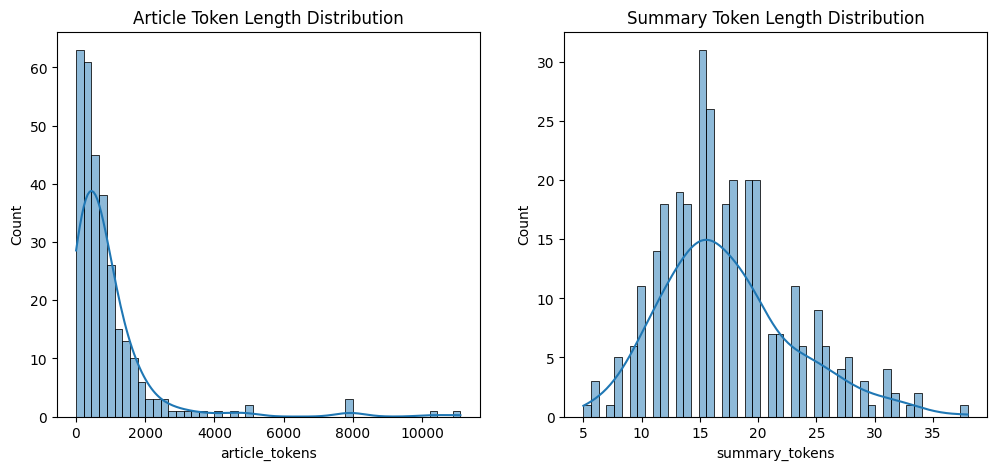

In [18]:
# Token Length Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["article_tokens"], bins=50, kde=True)
plt.title("Article Token Length Distribution")

plt.subplot(1,2,2)
sns.histplot(df["summary_tokens"], bins=50, kde=True)
plt.title("Summary Token Length Distribution")

plt.show()

In [19]:
# Truncation Analysis

max_len = 512

truncated_count = (df["article_tokens"] > max_len).sum()
total = len(df)

print("Total samples:", total)
print("Truncated samples:", truncated_count)
print("Percentage truncated:", (truncated_count/total)*100)

Total samples: 300
Truncated samples: 156
Percentage truncated: 52.0


Average token compression: 0.12445116272385495


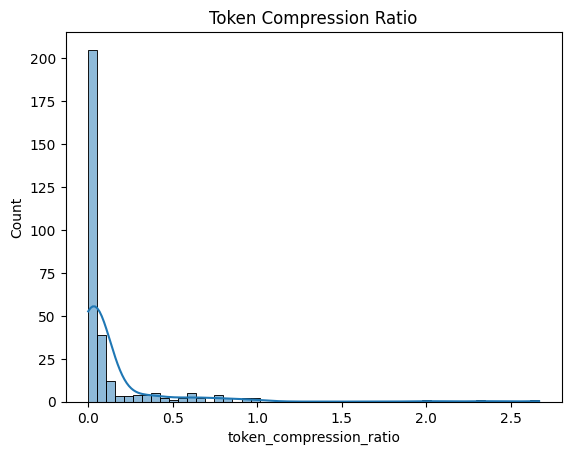

In [20]:
# Token Compression Ratio

df["token_compression_ratio"] = df["summary_tokens"] / df["article_tokens"]

print("Average token compression:", df["token_compression_ratio"].mean())

sns.histplot(df["token_compression_ratio"], bins=50, kde=True)
plt.title("Token Compression Ratio")
plt.show()

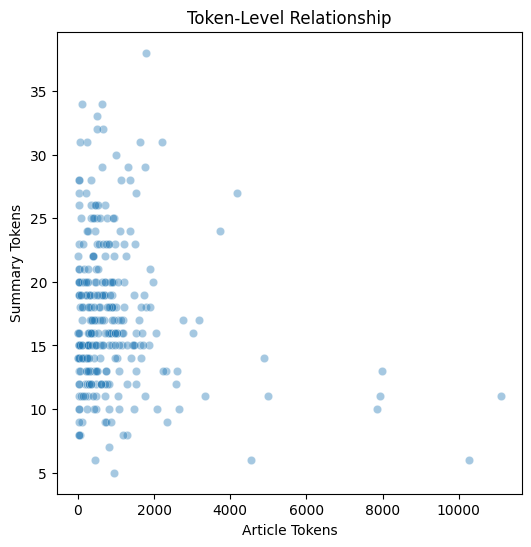

In [21]:
# Article vs Summary (Token Level)
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=df["article_tokens"],
    y=df["summary_tokens"],
    alpha=0.4
)
plt.xlabel("Article Tokens")
plt.ylabel("Summary Tokens")
plt.title("Token-Level Relationship")
plt.show()

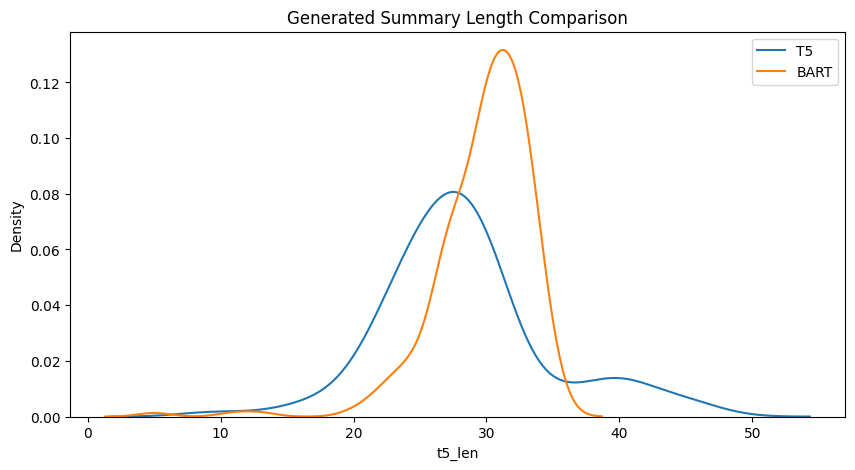

In [24]:
# Model Output Length Analysis
# Generated summary lengths
clean_df["t5_len"] = clean_df["t5-small_summary"].apply(lambda x: len(str(x).split()))
clean_df["bart_len"] = clean_df["bart-base_summary"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,5))

sns.kdeplot(clean_df["t5_len"], label="T5")
sns.kdeplot(clean_df["bart_len"], label="BART")

plt.title("Generated Summary Length Comparison")
plt.legend()
plt.show()